In [473]:
# from common import *
from my import *

import os
import random
import pickle
from pathlib import Path
from IPython.display import display, HTML

from tqdm import tqdm
from itertools import product
import joblib
from joblib import Parallel, delayed, parallel_backend

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

import time
import datetime
from datetime import datetime
from timeit import default_timer as timer
from dateutil.relativedelta import relativedelta

from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.decomposition import PCA
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif, chi2, RFE
from sklearn.preprocessing import StandardScaler, RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from lightgbm import LGBMClassifier
from xgboost import XGBRegressor, XGBClassifier

plt.rcParams['axes.unicode_minus'] = False
%matplotlib inline
%config InlineBackend.figure_format='retina'

# set random seed for reproducibility
def set_seeds(seed=777):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

SEED = 777
set_seeds(SEED)
print(f'Random seed set to: {SEED}')

# checking
set_seeds(SEED)
print(np.random.rand(3))
set_seeds(SEED)
print(np.random.rand(3))

Random seed set to: 777
[0.15266373 0.30235661 0.06203641]
[0.15266373 0.30235661 0.06203641]


In [3]:
def print_cols(df, n=5): 
    with pd.option_context('display.max_columns',None):
        # with pd.option_context('display.float_format', '{:,.4f}'.format):
            print(df.shape)
            display(df[:n])

# Load Data

In [453]:
with open('X_imputed.pkl', 'rb') as file: 
    X_imputed = pickle.load(file)
with open('y.pkl', 'rb') as file: 
    y = pickle.load(file)

In [290]:
X_imputed.columns

Index(['sleep_time_weekdays_usual_hours', 'age_years',
       'trouble_sleeping_last_2_weeks', 'sleep_time_weekends_usual_hours',
       'feeling_down_last_2_weeks', 'mid_arm_circumference_cm',
       'teeth_gums_health_rating', 'weight_last_1_year_pounds',
       'sleep_disturbance_score', 'minutes_sedentary_activity',
       'family_income_to_poverty_ratio', 'weight_kg', 'total_deliveries',
       'estradiol_pg_mL', 'systolic_bp_reading1_mmHg', 'estrone_sulfate_pg_mL',
       'race_hispanic_origin', 'work_type_last_week', 'sleep_risk_category',
       'weight_change_category', 'fatigue_flag', 'gender', 'smoking_status',
       'education_level', 'race_hispanic_origin_with_asian', 'marital_status',
       'job_difficulty_due_to_mouth_last_year_frequent',
       'used_any_tobacco_last_5_days', 'sedentary_level', 'ever_told_copd'],
      dtype='object')

# Modeling / Prediction

## Base Model

AUC-ROC
- simple_if_else_model -> predict_proba X; 0/1 only
- --> sum(conditions) / len(conditions))

respondent_id
109266    22.0
109267     0.0
109268    22.0
Name: sleep_time_weekdays_usual_hours, dtype: float64
respondent_id
109266    False
109267    False
109268    False
Name: sleep_time_weekdays_usual_hours, dtype: bool


<Axes: xlabel='is_sleep_deprived', ylabel='sleep_time_weekdays_usual_hours'>

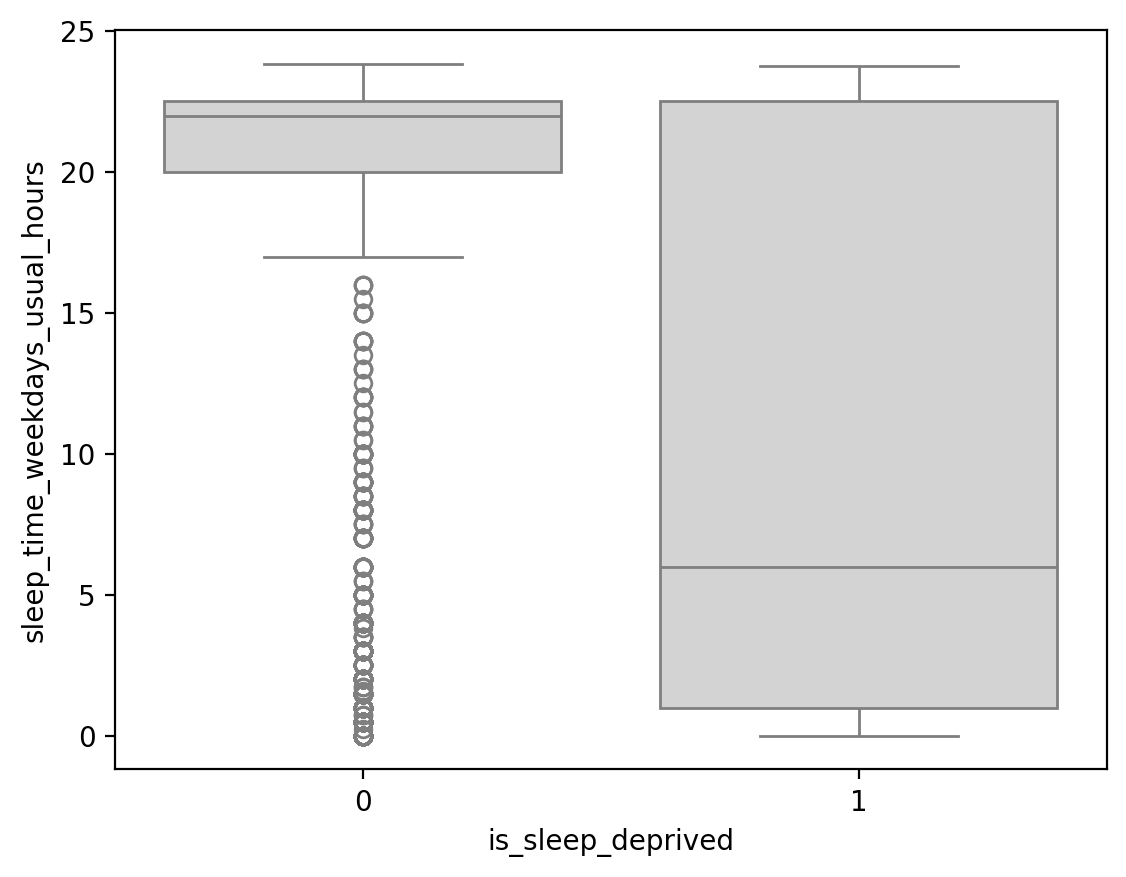

In [215]:
print(X_imputed.loc[:, 'sleep_time_weekdays_usual_hours'][:3])
print(((X_imputed.loc[:, 'sleep_time_weekdays_usual_hours'] > 1) & (X_imputed.loc[:, 'sleep_time_weekdays_usual_hours'] < 6))[:3])

# X_imputed['sleep_time_weekdays_usual_hours'].plot(kind='hist')
sns.boxplot(x=y, y=X_imputed['sleep_time_weekdays_usual_hours'])

In [393]:
X_imputed['sedentary_level'].unique()

array(['moderate', 'high', 'low', 'Missing', 'very_high'], dtype=object)

In [472]:
# define simple if-else model
def simple_if_else_model(X):
    # predict based on rules
    predictions = []
    proba = []
    for idx in X.index:
        conditions = [
            (X.loc[idx, 'sleep_time_weekdays_usual_hours'] > 0.0) & (X.loc[idx, 'sleep_time_weekdays_usual_hours'] < 8.0), # bedtime b/w 12am and 8am
            (X.loc[idx, 'sleep_time_weekends_usual_hours'] > 0.0) & (X.loc[idx, 'sleep_time_weekends_usual_hours'] < 8.0),
            # X.loc[idx, 'sleep_disturbance_score'] > 3, # high disturbance (> 3)
            # X.loc[idx, 'sleep_risk_category'] == 'High Risk', # high risk category
            (X.loc[idx, 'age_years'] > 29) & (X.loc[idx, 'age_years'] < 60), # age b/w 30 and 60
            # (X.loc[idx, 'age_years'] > 40),
            X.loc[idx, 'smoking_status'] in ['current_everyday','current_somedays'], # current smoker
            # X.loc[idx, 'race_hispanic_origin'] in ['Non-Hispanic Black'], # black
            X.loc[idx, 'sedentary_level'] in ['very_high'], # very high sedentary level
            # X.loc[idx, 'fatigue_flag'] == 1
        ]
        # predict 1 if 2 or more conditions are true
        if sum(conditions) >= 2:
            predictions.append(1)
        else:
            predictions.append(0)
        # calculate pseudo-probability
        proba.append(sum(conditions) / len(conditions))
    return np.array(predictions), np.array(proba)

# split data into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=SEED, stratify=y
)
# --> splitting using X_imputed

# predict on test set
y_pred, y_pred_proba = simple_if_else_model(X_test)

# classification performance
print('\nclassification report for simple if-else model:')
print(classification_report(y_test, y_pred))

# 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = {'accuracy': [], 'sensitivity': [], 'f1_class1': [], 'f1_macro': [], 'auc_roc': []}
for train_idx, val_idx in skf.split(X_imputed, y):
    # split data
    X_cv_train, X_cv_val = X_imputed.iloc[train_idx], X_imputed.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]
    # predict with if-else model
    y_cv_pred, y_cv_pred_proba = simple_if_else_model(X_cv_val)
    # calculate metrics for each fold
    cv_scores['accuracy'].append(accuracy_score(y_cv_val, y_cv_pred))
    cv_scores['sensitivity'].append(recall_score(y_cv_val, y_cv_pred, pos_label=1))
    cv_scores['f1_class1'].append(f1_score(y_cv_val, y_cv_pred, pos_label=1))
    cv_scores['f1_macro'].append(f1_score(y_cv_val, y_cv_pred, average='macro'))
    cv_scores['auc_roc'].append(roc_auc_score(y_cv_val, y_cv_pred_proba))

# cross-validation results
print('\n5-fold stratified cv results:')
for metric in cv_scores:
    # print mean and std for each metric
    print(f'{metric}: mean: {np.mean(cv_scores[metric]):.3f}, std: {np.std(cv_scores[metric]):.3f}')


classification report for simple if-else model:
              precision    recall  f1-score   support

           0       0.84      0.81      0.82      2885
           1       0.39      0.44      0.41       803

    accuracy                           0.73      3688
   macro avg       0.61      0.62      0.62      3688
weighted avg       0.74      0.73      0.73      3688


5-fold stratified cv results:
accuracy: mean: 0.724, std: 0.006
sensitivity: mean: 0.439, std: 0.016
f1_class1: mean: 0.409, std: 0.013
f1_macro: mean: 0.615, std: 0.008
auc_roc: mean: 0.653, std: 0.008


## XGBClassifier

- XGBoost
    - make all variables numeric -> encoding

In [470]:
# encode categorical cols to numeric codes (before splitting)
X_encoded = X_imputed.copy()
categorical_cols = X_imputed.select_dtypes(include=['object']).columns
for col in categorical_cols:
    X_encoded[col] = X_encoded[col].astype('category').cat.codes # convert to category and get codes
    X_encoded[col] = X_encoded[col].replace(-1, np.nan) # handle any -1 values (missing after encoding)

# calculate scale_pos_weight for class imbalance
class_counts = y.value_counts()
# set weight for minority class to balance classes (class 0 / class 1)
scale_pos_weight = class_counts[0] / class_counts[1] # ratio of class 0 to class 1

# train/test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=SEED, stratify=y
)
# --> splitting using X_encoded

### Hyperparameter Tuning
- GridSearch X
    - --> manual grid search 

In [471]:
# function to evaluate one parameter set
def evaluate_params(params, X_train, y_train, skf):
    max_depth, learning_rate, n_estimators, scale_weight = params
    # initialize model
    model = XGBClassifier(
        eval_metric='logloss',
        random_state=SEED,
        enable_categorical=False, # use numeric codes instead of categories
        max_depth=max_depth, # limit tree depth to avoid overfitting
        learning_rate=learning_rate, # slower learning for better generalization
        n_estimators=n_estimators, # use more trees for better fit
        scale_pos_weight=scale_weight, # increase weight for minority class
        n_jobs=1 # disable xgboost internal parallel
    )
    # calculate metric with cross-validation
    cv_scores = []
    for train_idx, val_idx in skf.split(X_train, y_train):
        # split data with stratified folds to keep class ratio
        X_cv_train, X_cv_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_cv_train, y_cv_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        # train model with current parameter set
        model.fit(X_cv_train, y_cv_train)
        # predict on validation set
        y_cv_pred = model.predict(X_cv_val)
        # calculate metric score for each fold
        cv_scores.append(f1_score(y_cv_val, y_cv_pred, pos_label=1)) # f1-score for class 1
        # cv_scores.append(recall_score(y_cv_val, y_cv_pred, pos_label=1)) # recall for class 1
    
    # return average metric score across folds and params
    return np.mean(cv_scores), params

# define parameter combinations
param_combinations = list(product(
    [3, 5, 7], # max_depth
    [0.01, 0.05, 0.1], # learning_rate
    [100, 200], # n_estimators
    [scale_pos_weight, scale_pos_weight * 2] # scale_pos_weight
))

# perform manual grid search with 5-fold stratified cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# parallel processing with joblib and tqdm
results = Parallel(n_jobs=-1, verbose=0)(
    delayed(evaluate_params)(params, X_train, y_train, skf)
    for params in tqdm(param_combinations, desc='tuning parameters')
)

# find best parameters
best_score = 0
best_params = None
best_model = None
for mean_score, params in results:
    # print current parameters and score
    print(f'params: max_depth={params[0]}, learning_rate={params[1]}, n_estimators={params[2]}, scale_pos_weight={params[3]:.2f}, cv score: {mean_score:.3f}')
    # update best model if metric score improves
    if mean_score > best_score:
        best_score = mean_score
        # current best parameters
        best_params = {
            'max_depth': params[0],
            'learning_rate': params[1],
            'n_estimators': params[2],
            'scale_pos_weight': params[3]
        }
        # xgboost with tuned parameters
        best_model = XGBClassifier(
            eval_metric='logloss',
            random_state=SEED,
            enable_categorical=False,
            max_depth=params[0],
            learning_rate=params[1],
            n_estimators=params[2],
            scale_pos_weight=params[3],
            n_jobs=1
        )

# best parameters and score
print('\nbest parameters:')
print(best_params)
print(f'best cv score: {best_score:.3f}')

# train best model on full training data
best_model.fit(X_train, y_train)

# predict on test set
y_pred = best_model.predict(X_test)

# classification performance
print('\nclassification report:')
print(classification_report(y_test, y_pred))

# perform 5-fold stratified cv with best model
# cv_scores = []
cv_scores = {'accuracy': [], 'sensitivity': [], 'f1_class1': [], 'f1_macro': [], 'auc_roc': []}
for train_idx, val_idx in skf.split(X_encoded, y):
    # split data with stratified folds to keep class ratio
    X_cv_train, X_cv_val = X_encoded.iloc[train_idx], X_encoded.iloc[val_idx]
    y_cv_train, y_cv_val = y.iloc[train_idx], y.iloc[val_idx]
    # train best model
    cv_model = best_model
    cv_model.fit(X_cv_train, y_cv_train)
    # predict on validation set
    y_cv_pred = cv_model.predict(X_cv_val)
    y_cv_pred_proba = cv_model.predict_proba(X_cv_val)[:, 1]
    # calculate metrics for each fold
    cv_scores['accuracy'].append(accuracy_score(y_cv_val, y_cv_pred))
    cv_scores['sensitivity'].append(recall_score(y_cv_val, y_cv_pred, pos_label=1))
    cv_scores['f1_class1'].append(f1_score(y_cv_val, y_cv_pred, pos_label=1))
    cv_scores['f1_macro'].append(f1_score(y_cv_val, y_cv_pred, average='macro'))
    cv_scores['auc_roc'].append(roc_auc_score(y_cv_val, y_cv_pred_proba))

# print cross-validation results
# print(f'mean: {np.mean(cv_scores):.3f}, std: {np.std(cv_scores):.3f}')
print('\n5-fold stratified cv results:')
for metric in cv_scores:
    # print mean and std for each metric
    print(f'{metric}: mean: {np.mean(cv_scores[metric]):.3f}, std: {np.std(cv_scores[metric]):.3f}')

# feature importance
feature_importance = pd.Series(best_model.feature_importances_, index=X_encoded.columns)
print('\ntop 10 feature importance:')
print(feature_importance.sort_values(ascending=False).head(10))



 parameters:   0%|                                 | 0/36 [00:00<?, ?it/s]

 parameters:  31%|███████▎                | 11/36 [00:00<00:00, 50.82it/s]

 parameters:  47%|███████████▎            | 17/36 [00:00<00:00, 46.78it/s]

 parameters:  61%|██████████████▋         | 22/36 [00:03<00:03,  4.51it/s]

tuning parameters: 100%|████████████████████████| 36/36 [00:04<00:00,  8.09it/s]


params: max_depth=3, learning_rate=0.01, n_estimators=100, scale_pos_weight=3.59, cv score: 0.491
params: max_depth=3, learning_rate=0.01, n_estimators=100, scale_pos_weight=7.19, cv score: 0.405
params: max_depth=3, learning_rate=0.01, n_estimators=200, scale_pos_weight=3.59, cv score: 0.504
params: max_depth=3, learning_rate=0.01, n_estimators=200, scale_pos_weight=7.19, cv score: 0.445
params: max_depth=3, learning_rate=0.05, n_estimators=100, scale_pos_weight=3.59, cv score: 0.515
params: max_depth=3, learning_rate=0.05, n_estimators=100, scale_pos_weight=7.19, cv score: 0.458
params: max_depth=3, learning_rate=0.05, n_estimators=200, scale_pos_weight=3.59, cv score: 0.517
params: max_depth=3, learning_rate=0.05, n_estimators=200, scale_pos_weight=7.19, cv score: 0.468
params: max_depth=3, learning_rate=0.1, n_estimators=100, scale_pos_weight=3.59, cv score: 0.517
params: max_depth=3, learning_rate=0.1, n_estimators=100, scale_pos_weight=7.19, cv score: 0.468
params: max_depth=3, l

## Stacking

In [494]:
# train/test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=SEED, stratify=y
)
# --> splitting using X_encoded

# select top 10 features based on previous xgboost importance
top_features = top_30_features[:10]

# use top features for meta-data
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

# scale features for svm
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# define base models
base_models = [
    # random forest with balanced weights
    ('rf', RandomForestClassifier(
        n_estimators=100, max_depth=5, class_weight='balanced', random_state=SEED
    )),
    # lightgbm with scale_pos_weight
    ('lgbm', LGBMClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, random_state=SEED, verbose=-1
    )),
    # svm with balanced weights
    ('svm', SVC(
        probability=True, class_weight='balanced', random_state=SEED
    ))
]

# initialize k-fold for stacking
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# prepare meta-data arrays
meta_train = np.zeros((X_train.shape[0], len(base_models)))
meta_test = np.zeros((X_test.shape[0], len(base_models)))

# function to train and predict for one fold
def train_fold(name, model, X_train_current, X_test_current, train_idx, val_idx, y_train):
    # split data
    if name == 'svm':
        # use numpy indexing for scaled data
        X_kf_train = X_train_current[train_idx]
        X_kf_val = X_train_current[val_idx]
    else:
        # use dataframe indexing for rf and lgbm
        X_kf_train = X_train_current.iloc[train_idx]
        X_kf_val = X_train_current.iloc[val_idx]
    y_kf_train = y_train.iloc[train_idx]
    
    # fit model
    model.fit(X_kf_train, y_kf_train)
    
    # predict probabilities for class 1
    if name == 'svm':
        val_preds = model.predict_proba(X_kf_val)[:, 1]
        test_preds = model.predict_proba(X_test_current)[:, 1]
    else:
        val_preds = model.predict_proba(X_kf_val)[:, 1]
        test_preds = model.predict_proba(X_test_current)[:, 1]
    
    return val_preds, test_preds, val_idx

# generate meta-data with k-fold stacking and parallel processing
for i, (name, model) in enumerate(tqdm(base_models, desc='training base models')):
    # use scaled data for svm, dataframe for others
    X_train_current = X_train_scaled if name == 'svm' else X_train
    X_test_current = X_test_scaled if name == 'svm' else X_test
    
    # store test predictions
    test_preds = np.zeros(X_test.shape[0])
    
    # parallelize k-fold training
    results = Parallel(n_jobs=-1)(
        delayed(train_fold)(name, model, X_train_current, X_test_current, train_idx, val_idx, y_train)
        for train_idx, val_idx in kfold.split(X_train, y_train)
    )
    
    # collect results
    for val_preds, fold_test_preds, val_idx in results:
        # store validation predictions
        meta_train[val_idx, i] = val_preds
        # accumulate test predictions
        test_preds += fold_test_preds / kfold.n_splits
    
    # store test predictions
    meta_test[:, i] = test_preds

# combine meta-data with top original features
meta_train = np.hstack([meta_train, X_train_top])
meta_test = np.hstack([meta_test, X_test_top])

# scale meta-data for logistic regression
meta_scaler = StandardScaler()
meta_train_scaled = meta_scaler.fit_transform(meta_train)
meta_test_scaled = meta_scaler.transform(meta_test)

# apply smote to scaled meta-data
# smote = SMOTE(random_state=SEED)
# meta_train_smote, y_train_smote = smote.fit_resample(meta_train_scaled, y_train)

# no SMOTE --> will use class_weight='balanced' only
meta_train_smote, y_train_smote = meta_train_scaled, y_train 

# train meta-model (logistic regression)
meta_model = LogisticRegression(
    class_weight='balanced', random_state=SEED, max_iter=1000
)
meta_model.fit(meta_train_smote, y_train_smote)

# predict on test set
y_pred = meta_model.predict(meta_test_scaled)

# classification performance
print('\nclassification report:')
print(classification_report(y_test, y_pred))

# perform 5-fold stratified cv for meta-model and collect coefficients
# cv_scores = []
cv_scores = {'accuracy': [], 'sensitivity': [], 'f1_class1': [], 'f1_macro': [], 'auc_roc': []}
coefficients_list = []
for train_idx, val_idx in kfold.split(meta_train_scaled, y_train):
    # split data
    X_cv_train = meta_train_scaled[train_idx]
    X_cv_val = meta_train_scaled[val_idx]
    y_cv_train = y_train.iloc[train_idx]
    y_cv_val = y_train.iloc[val_idx]

    # apply smote to training fold
    # X_cv_train_smote, y_cv_train_smote = smote.fit_resample(X_cv_train, y_cv_train)
    # no SMOTE
    X_cv_train_smote, y_cv_train_smote = X_cv_train, y_cv_train
    
    # train meta-model
    cv_model = LogisticRegression(
        class_weight='balanced', random_state=SEED, max_iter=1000
    ) # class weights balanced
    cv_model.fit(X_cv_train_smote, y_cv_train_smote)

    # store coefficients
    coefficients_list.append(cv_model.coef_[0])
    
    # predict on validation set
    y_cv_pred = cv_model.predict(X_cv_val)
    y_cv_pred_proba = cv_model.predict_proba(X_cv_val)[:, 1] # calcualte class 1 proba for more accurate AUC-ROC
    
    # calculate metrics
    cv_scores['accuracy'].append(accuracy_score(y_cv_val, y_cv_pred))
    cv_scores['sensitivity'].append(recall_score(y_cv_val, y_cv_pred, pos_label=1))
    cv_scores['f1_class1'].append(f1_score(y_cv_val, y_cv_pred, pos_label=1))
    cv_scores['f1_macro'].append(f1_score(y_cv_val, y_cv_pred, average='macro'))
    cv_scores['auc_roc'].append(roc_auc_score(y_cv_val, y_cv_pred_proba))

# cross-validation results
print('\n5-fold stratified cv results:')
for metric in cv_scores:
    # print mean and std for each metric
    print(f'{metric}: mean: {np.mean(cv_scores[metric]):.3f}, std: {np.std(cv_scores[metric]):.3f}')

# calculate average coefficients and odds ratios
avg_coefficients = np.mean(coefficients_list, axis=0)
avg_odds_ratios = np.exp(avg_coefficients)

# display feature importance using coefficients and odds ratios
col_name_list = [m[0] for m in base_models] + top_features
feature_importance = pd.DataFrame({
    'Feature': col_name_list,
    'Coefficient': avg_coefficients,
    'Odds Ratio': avg_odds_ratios
})
print("\nFeature Importance (Coefficient and Odds Ratio):")
print(feature_importance.sort_values(by='Coefficient', ascending=False))



ng base models:   0%|                               | 0/3 [00:00<?, ?it/s]

ng base models:  33%|███████▋               | 1/3 [00:02<00:04,  2.46s/it]

ng base models:  67%|███████████████▎       | 2/3 [00:04<00:02,  2.03s/it]

training base models: 100%|███████████████████████| 3/3 [00:30<00:00, 10.29s/it]


classification report:
              precision    recall  f1-score   support

           0       0.89      0.72      0.79      2885
           1       0.40      0.68      0.50       803

    accuracy                           0.71      3688
   macro avg       0.64      0.70      0.65      3688
weighted avg       0.78      0.71      0.73      3688


5-fold stratified cv results:
accuracy: mean: 0.714, std: 0.009
sensitivity: mean: 0.695, std: 0.009
f1_class1: mean: 0.514, std: 0.008
f1_macro: mean: 0.656, std: 0.008
auc_roc: mean: 0.770, std: 0.005

Feature Importance (Coefficient and Odds Ratio):
                            Feature  Coefficient  Odds Ratio
0                                rf     0.689551    1.992821
1                              lgbm     0.622915    1.864355
3   sleep_time_weekdays_usual_hours     0.143693    1.154530
8   sleep_time_weekends_usual_hours     0.072670    1.075375
11              sleep_risk_category     0.051979    1.053354
6               work_type_las

In [433]:
meta_train.shape

(14750, 13)

In [445]:
pd.DataFrame(meta_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.441596,0.519724,0.107133,23.0,1.0,64.0,3.0,0.0,23.0,0.0,0.0,1.0,1.0
1,0.505848,0.659147,0.381465,23.0,3.0,68.0,4.0,0.0,0.0,0.0,3.0,1.0,3.0
2,0.366854,0.245355,0.105807,21.0,2.0,70.0,3.0,0.0,21.0,0.0,4.0,1.0,4.0
3,0.419394,0.499650,0.192109,22.5,0.0,79.0,3.0,3.0,22.5,0.0,3.0,1.0,0.0
4,0.371543,0.223438,0.175590,19.0,2.0,75.0,4.0,0.0,21.0,0.0,4.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14745,0.464865,0.630067,0.407567,22.0,2.0,54.0,4.0,1.0,0.5,0.0,4.0,1.0,4.0
14746,0.448637,0.255116,0.151929,23.0,4.0,34.0,4.0,0.0,0.0,0.0,0.0,1.0,4.0
14747,0.397043,0.435374,0.077149,23.5,2.0,41.0,4.0,0.0,23.5,0.0,4.0,1.0,4.0
14748,0.395107,0.440334,0.110081,22.5,2.0,67.0,4.0,0.0,23.0,0.0,4.0,1.0,4.0


In [435]:
X_train_top.shape

(14750, 10)

In [438]:
val_preds.shape, test_preds.shape

((2950,), (3688,))

In [442]:
val_preds.shape[0] * 5

14750

In [443]:
val_preds

array([0.10713272, 0.20937873, 0.21271218, ..., 0.39482304, 0.39552961,
       0.1519292 ])